In [5]:
# --- Project imports --- #
# Add the 'src' directory to the Python path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))
# Local module imports
from models.resnet50 import build_model
from utils.utils import load_image_datasets, one_hot_labels, apply_mixup
from metrics.classification import SparseMacroF1  # custom metric

# --- Third-party libraries --- #
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import (
    CSVLogger,
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.optimizers import Adam

In [6]:
dataset_path = PROJECT_ROOT / "data"

train_dataset, validation_dataset, test_dataset = load_image_datasets(dataset_path)

# --- Inspect class mapping --- #
class_names = train_dataset.class_names
class_to_idx = {name: i for i, name in enumerate(class_names)}

# --- Apply MixUp to generate interpolated training samples --- #
train_dataset = train_dataset.map(apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(
    one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE
)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("Class mapping:", class_to_idx)

# Inspect first batch
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Batch size:", labels.shape)


Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Class mapping: {'Albrecht_Durer': 0, 'Boris_Kustodiev': 1, 'Camille_Pissarro': 2, 'Childe_Hassam': 3, 'Claude_Monet': 4, 'Edgar_Degas': 5, 'Eugene_Boudin': 6, 'Gustave_Dore': 7, 'Ilya_Repin': 8, 'Ivan_Aivazovsky': 9, 'Ivan_Shishkin': 10, 'John_Singer_Sargent': 11, 'Marc_Chagall': 12, 'Martiros_Saryan': 13, 'Nicholas_Roerich': 14, 'Pablo_Picasso': 15, 'Paul_Cezanne': 16, 'Pierre_Auguste_Renoir': 17, 'Pyotr_Konchalovsky': 18, 'Raphael_Kirchner': 19, 'Rembrandt': 20, 'Salvador_Dali': 21, 'Vincent_van_Gogh': 22}
Images shape: (32, 224, 224, 3)
Batch size: (32, 23)


In [7]:
def build_callbacks(csv_append):
    return [
        CSVLogger("./results/training_log_regularize.csv", append=csv_append),
        EarlyStopping(
            monitor="val_f1_score",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            mode="max",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            "./checkpoint/best_model_regularized.keras",
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
        ),
    ]

In [8]:
# --- Stage 1: train the classifier head with the backbone frozen --- #
model = build_model(
    num_classes=23, trainable_layers=0, dropout_rate=0.4, l2_strength=1e-4
)

model.compile(
    optimizer=Adam(learning_rate=1e-3, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=[F1Score(average="macro", threshold=None, name="f1_score")],
)

history_stage_1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=8,
    callbacks=build_callbacks(csv_append=False),
)

Epoch 1/8
 68/292 ━━━━━━━━━━━━━━━━━━━━ 2:28 663ms/step - f1_score: 0.1467 - loss: 3.2902

KeyboardInterrupt: 

In [ ]:
# --- Stage 2: fine-tune only the top 30 ResNet layers --- #
base_model = None
for layer in model.layers:
    if "resnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("ResNet backbone not found inside the model.")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

trainable_backbone_layers = sum(1 for layer in base_model.layers if layer.trainable)
print("Trainable backbone layers:", trainable_backbone_layers)

model.compile(
    optimizer=Adam(learning_rate=1e-5, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[F1Score(average="macro", threshold=None, name="f1_score")],
)

history_stage_2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=build_callbacks(csv_append=True),
)


In [ ]:
history_dict = {
    "loss": history_stage_1.history["loss"] + history_stage_2.history["loss"],
    "val_loss": history_stage_1.history["val_loss"]
    + history_stage_2.history["val_loss"],
    "macro_f1": history_stage_1.history["macro_f1"]
    + history_stage_2.history["macro_f1"],
    "val_macro_f1": history_stage_1.history["val_macro_f1"]
    + history_stage_2.history["val_macro_f1"],
}

In [ ]:
# model = build_model(
#     num_classes=23,
#     trainable_layers=30,
#     dropout_rate=0.4,
#     l2_strength=1e-4,
# )

# # --- Compile --- #
# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss="categorical_crossentropy",
#     metrics=[F1Score(average="macro", threshold=None, name="f1_score")],
# )

# # --- Callbacks --- #
# csv_logger = CSVLogger("training_log.csv", append=True)

# early_stopping = EarlyStopping(
#     monitor="val_f1_score",  # now guaranteed to exist
#     patience=5,
#     mode="max",
#     restore_best_weights=True,
# )

# lr_scheduler = ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.3,
#     patience=3,
#     min_lr=1e-6,
# )

# # --- Train --- #
# history = model.fit(
#     train_dataset,
#     validation_data=validation_dataset,
#     epochs=30,
#     callbacks=[csv_logger, early_stopping, lr_scheduler],
# )


In [ ]:
epochs = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict["loss"], "bo", label="Training loss")
plt.plot(epochs, history_dict["val_loss"], "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict["macro_f1"], "bo", label="Training macro_f1")
plt.plot(epochs, history_dict["val_macro_f1"], "b", label="Validation macro_f1")
plt.title("Macro F1")
plt.xlabel("Epochs")
plt.ylabel("Macro F1")
plt.legend()

plt.tight_layout()
plt.show()


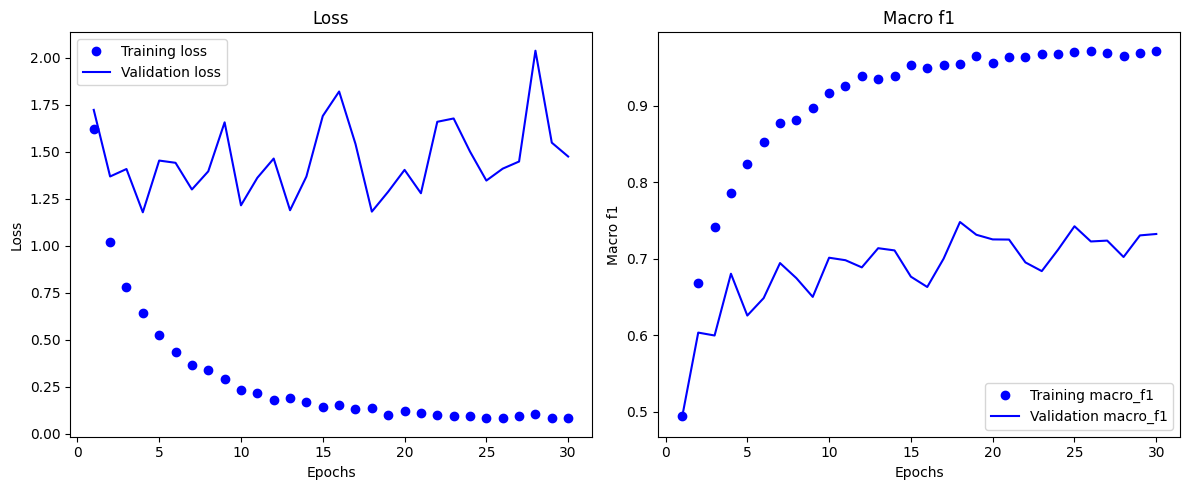

In [ ]:
history_dict = history.history

# Loss metrics
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
# Accuracy metrics
acc = history_dict["macro_f1"]
val_acc = history_dict["val_macro_f1"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training macro_f1")
plt.plot(epochs, val_acc, "b", label="Validation macro_f1")
plt.title("Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Macro f1")
plt.legend()

plt.tight_layout()
plt.show()
